# Latent tour: stitching 1-1 and 1-2

**The point.** To play a level we need the encoder of *that* level (it is the one that can read its images).
The controller can come from the *other* level, if we map the encoder's latents into that controller's space.
SAPS needs paired anchors to fit the map, and across levels there are no paired frames. With SCIL, anchors can be
made by just pairing random frames that share the same action (the old-repo recipe, now the method's
default: up to 100 pairs per action from the full training sets, `align.fit_action_pairs`), because SCIL latents are
organised by action. Without SCIL (plain BC), the same trick should work much worse.

0. **SCIL clusters actions** within each level (its own latent space), BC does not.
1. **No alignment**: the two levels' latent spaces are unrelated.
2. **BC + SAPS** and 3. **SCIL + SAPS**, with same-action anchors: the 1-1 latents mapped into the 1-2 space.
4. **Neighbours**: 1-1 frames next to their nearest 1-2 frame in the aligned space (pictures only).
5. **Does the other level's controller act correctly?** Encoder of the played level + map + other level's controller.

Nature CNN agents, v0. Models of the two levels use different seeds (same-seed models share their initialisation).

In [1]:
import sys
sys.path.insert(0, "..")  # the mario/ modules

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from sklearn.manifold import TSNE

from agents import DEVICE, embed, inputs, load_model
from align import action_pairs, fit_action_pairs
from data import CLASS_NAMES, DATA, EPISODES

ARCH, EVERY = "nature", 8  # encoder type; keep one frame out of EVERY
SEED = {"1-1": 0, "1-2": 1}  # different seeds per level: no shared initialisation
VAL_EP = {L: EPISODES[L][1][0] for L in SEED}  # one held-out episode per level
rng = np.random.default_rng(0)

## Helpers

In [2]:
def frames(level):
    # raw frames of the held-out episode (for display): (T, 240, 256, 3)
    z = np.load(next((DATA / "demos").glob(f"{level}_ep{VAL_EP[level]:03d}_*.npz")))
    return z["obs"][::EVERY]


def latents(method, level, eps, every=EVERY):
    # latents (N, 512) and action classes (N,) of the level's own encoder on those episodes
    enc, _ = load_model(ARCH, method, SEED[level], level, 0)
    X, y, _ = inputs(ARCH, level, 0, eps)
    return embed(ARCH, enc, X[::every]), y.numpy()[::every]


def same_action_map(method, src, tgt):
    # The method's anchors (align.fit_action_pairs): random pairs of training frames that share the action,
    # up to 100 per action, drawn from the full training sets; then Procrustes. Returns (R, b) mapping
    # src-encoder latents into the tgt-encoder space.
    Za, ya = latents(method, src, EPISODES[src][0], every=1)
    Zb, yb = latents(method, tgt, EPISODES[tgt][0], every=1)
    return fit_action_pairs(Za, Zb, ya, yb, rng)


def knn_action_acc(Zq, yq, Zr, yr, k=10):
    # balanced accuracy of predicting a frame's action by majority vote of its k nearest reference frames
    A = Zq / np.linalg.norm(Zq, axis=1, keepdims=True)
    B = Zr / np.linalg.norm(Zr, axis=1, keepdims=True)
    votes = yr[np.argsort(-(A @ B.T), axis=1)[:, :k]]
    pred = np.array([np.bincount(v, minlength=len(CLASS_NAMES)).argmax() for v in votes])
    return np.mean([(pred[yq == c] == c).mean() for c in np.unique(yq)])


def own_space(level):
    # BC vs SCIL, each in its own latent space: t-SNE of training (left) and held-out (right) frames
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    for row, method in zip(axes, ["bc", "scil"]):
        Zt, yt = latents(method, level, EPISODES[level][0])
        Zv, yv = latents(method, level, [VAL_EP[level]])
        P = TSNE(init="pca", random_state=0).fit_transform(np.concatenate([Zt, Zv]))
        for ax, Q, y, name in [(row[0], P[:len(Zt)], yt, "training frames"), (row[1], P[len(Zt):], yv, "held-out frames")]:
            for c in np.unique(y):
                ax.scatter(*Q[y == c].T, s=4, alpha=0.5, label=CLASS_NAMES[c])
            ax.set_title(f"{level} {method.upper()}: {name}")
            ax.set_xticks([]), ax.set_yticks([])
        row[1].set_title(row[1].get_title() + f" (10-NN action acc {knn_action_acc(Zv, yv, Zt, yt):.2f})")
    axes[0, 0].legend(markerscale=4, fontsize=8)
    plt.show()


def cluster_gallery(level, n=5):
    # SCIL: for each action, the held-out frames closest to that action's centroid (from training frames)
    Zt, yt = latents("scil", level, EPISODES[level][0])
    Zv, yv = latents("scil", level, [VAL_EP[level]])
    classes = [c for c in np.unique(yt) if (yt == c).sum() >= 20]
    fig, axes = plt.subplots(len(classes), n, figsize=(2.6 * n, 2.4 * len(classes)))
    for row, c in zip(axes, classes):
        d = np.linalg.norm(Zv - Zt[yt == c].mean(0), axis=1)
        for ax, i in zip(row, np.argsort(d)[:n]):
            ax.imshow(F[level][i])
            ax.set_title(f"true: {CLASS_NAMES[yv[i]]}", fontsize=9)
            ax.axis("off")
        row[0].text(-0.1, 0.5, CLASS_NAMES[c], transform=row[0].transAxes, ha="right", va="center", fontsize=12)
    fig.suptitle(f"{level} SCIL: held-out frames closest to each action centroid (row = centroid)")
    plt.show()


def pca2(Za, Zb):
    Z = np.concatenate([Za, Zb])
    mu = Z.mean(0)
    _, _, Vt = np.linalg.svd(Z - mu, full_matrices=False)
    return (Za - mu) @ Vt[:2].T, (Zb - mu) @ Vt[:2].T


def plot_spaces(title, Za, ya, Zb, yb, n_frames=5):
    # both levels in one PCA. Left: by level, with a few frames drawn at their position. Right: by action
    Pa, Pb = pca2(Za, Zb)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax.scatter(*Pa.T, s=5, alpha=0.3, label="1-1")
    ax.scatter(*Pb.T, s=5, alpha=0.3, label="1-2")
    for P, frs, color in [(Pa, F["1-1"], "C0"), (Pb, F["1-2"], "C1")]:
        for i in rng.choice(len(P), n_frames, replace=False):
            ax.add_artist(AnnotationBbox(OffsetImage(frs[i], zoom=0.16), P[i], bboxprops={"edgecolor": color, "lw": 2}))
    ax.legend()
    ax.set_title(f"{title}: by level")
    for c in np.union1d(ya, yb):
        ax2.scatter(*np.concatenate([Pa[ya == c], Pb[yb == c]]).T, s=5, alpha=0.4, label=CLASS_NAMES[c])
    ax2.legend(markerscale=3, fontsize=8)
    ax2.set_title(f"{title}: by action")
    plt.show()


def show_neighbours(title, Za, Zb, idx):
    # 1-1 frames (top) and their nearest 1-2 frame by cosine in the aligned space (bottom)
    A = Za / np.linalg.norm(Za, axis=1, keepdims=True)
    B = Zb / np.linalg.norm(Zb, axis=1, keepdims=True)
    nn = (A @ B.T).argmax(1)
    fig, axes = plt.subplots(2, len(idx), figsize=(3 * len(idx), 5.2))
    for k, i in enumerate(idx):
        axes[0, k].imshow(F["1-1"][i])
        axes[1, k].imshow(F["1-2"][nn[i]])
    for ax in axes.flat:
        ax.axis("off")
    fig.suptitle(f"{title}: 1-1 frame (top) and its nearest 1-2 frame in the aligned space (bottom)")
    plt.show()


@torch.no_grad()
def act(ctrl, Z):
    return ctrl(torch.from_numpy(Z).float().to(DEVICE)).argmax(1).cpu().numpy()


def stitch_check(method, play, other):
    # play `play` with its own encoder + map + controller of `other`, on held-out frames of `play`.
    # Returns agreement with the native agent of `play`, the native and stitched actions.
    enc, native_ctrl = load_model(ARCH, method, SEED[play], play, 0)
    _, other_ctrl = load_model(ARCH, method, SEED[other], other, 0)
    X, _, _ = inputs(ARCH, play, 0, [VAL_EP[play]])
    Z = embed(ARCH, enc, X[::EVERY])
    R, b = same_action_map(method, play, other)
    native, stitched, unmapped = act(native_ctrl, Z), act(other_ctrl, Z @ R.T + b), act(other_ctrl, Z)
    return (stitched == native).mean(), (unmapped == native).mean(), native, stitched

## Data: held-out frames of both levels

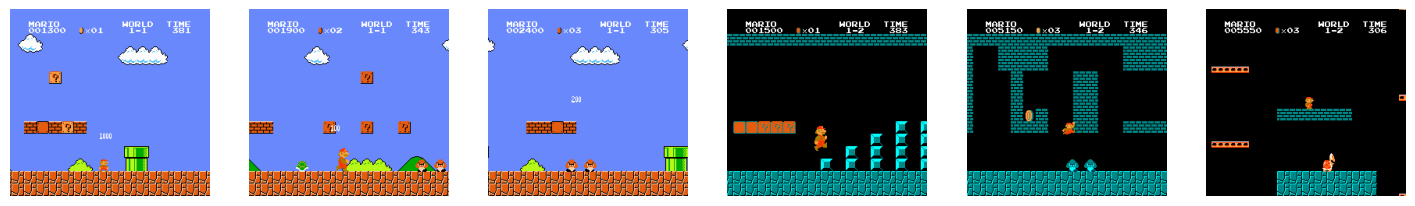

In [3]:
F = {L: frames(L) for L in SEED}
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, f in zip(axes, [F["1-1"][50], F["1-1"][150], F["1-1"][250], F["1-2"][50], F["1-2"][150], F["1-2"][250]]):
    ax.imshow(f)
    ax.axis("off")
plt.show()

## 0. SCIL clusters actions (each level in its own space)
On training frames, SCIL separates actions into clean clusters; BC does not. On held-out frames the SCIL clusters
overlap more: a frame's action is only ~40% predictable (balanced) for any model, because human play is noisy.

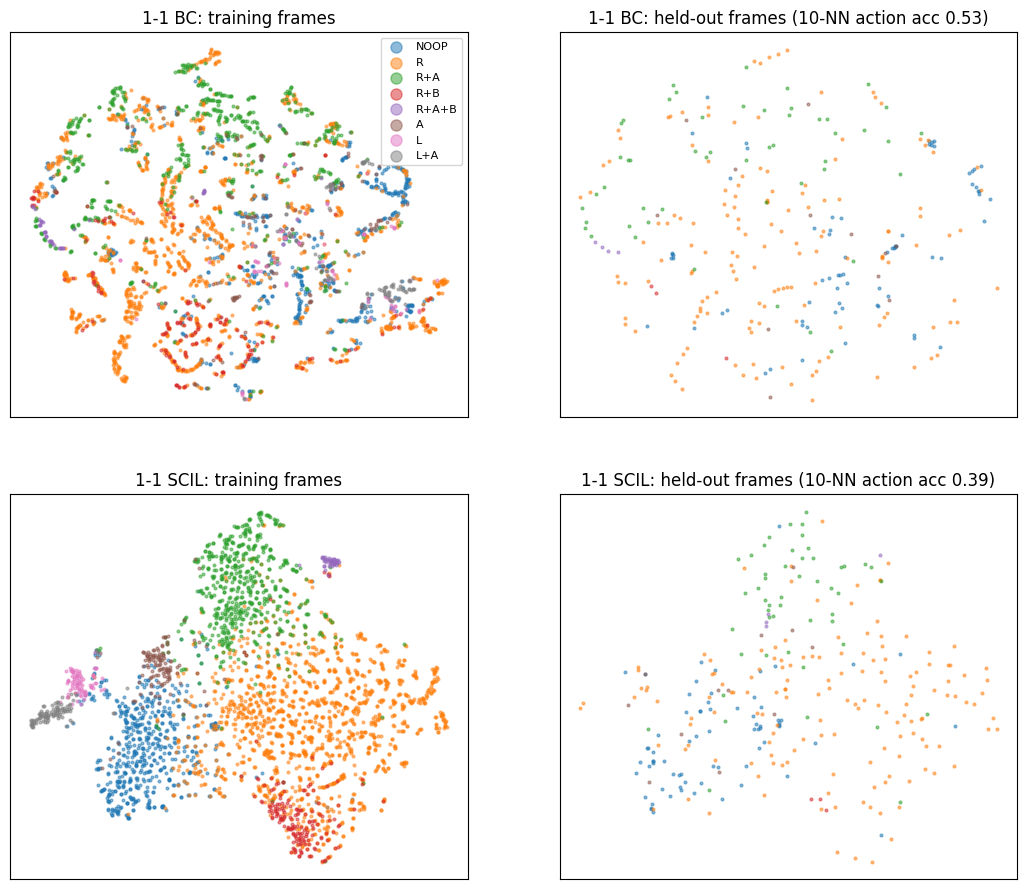

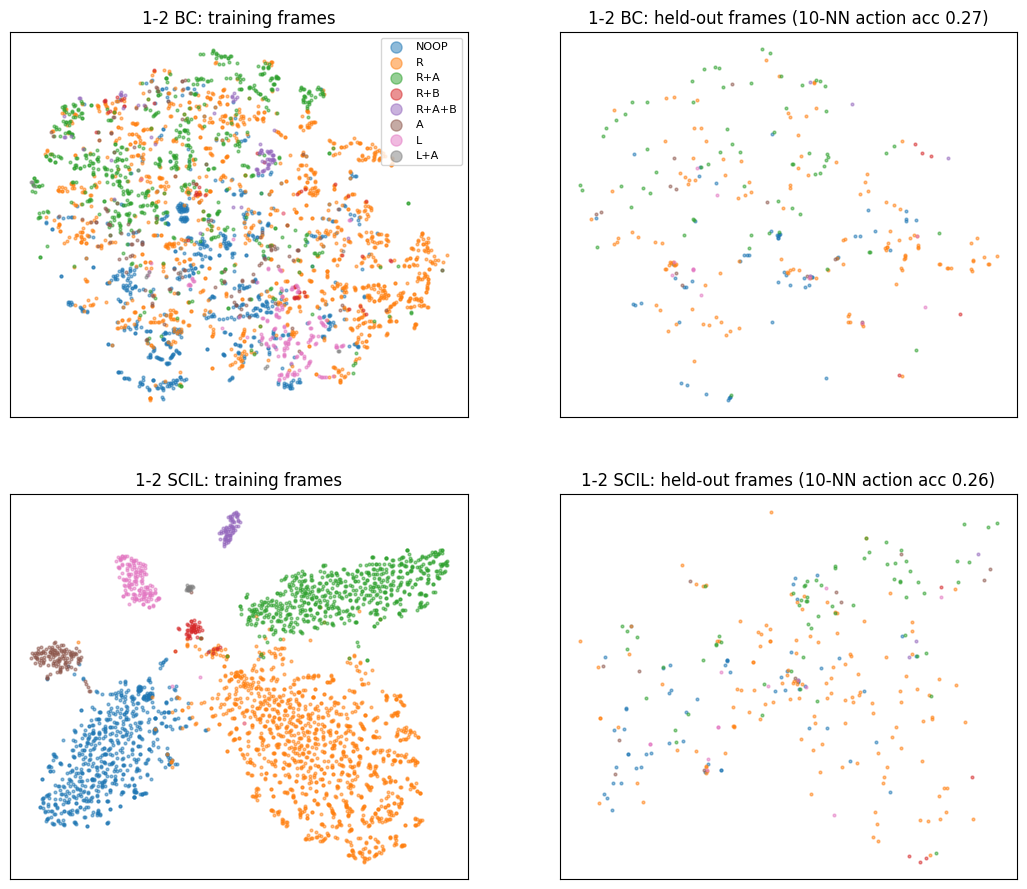

In [4]:
own_space("1-1")
own_space("1-2")

What each SCIL action cluster looks like: held-out frames closest to each action's centroid.

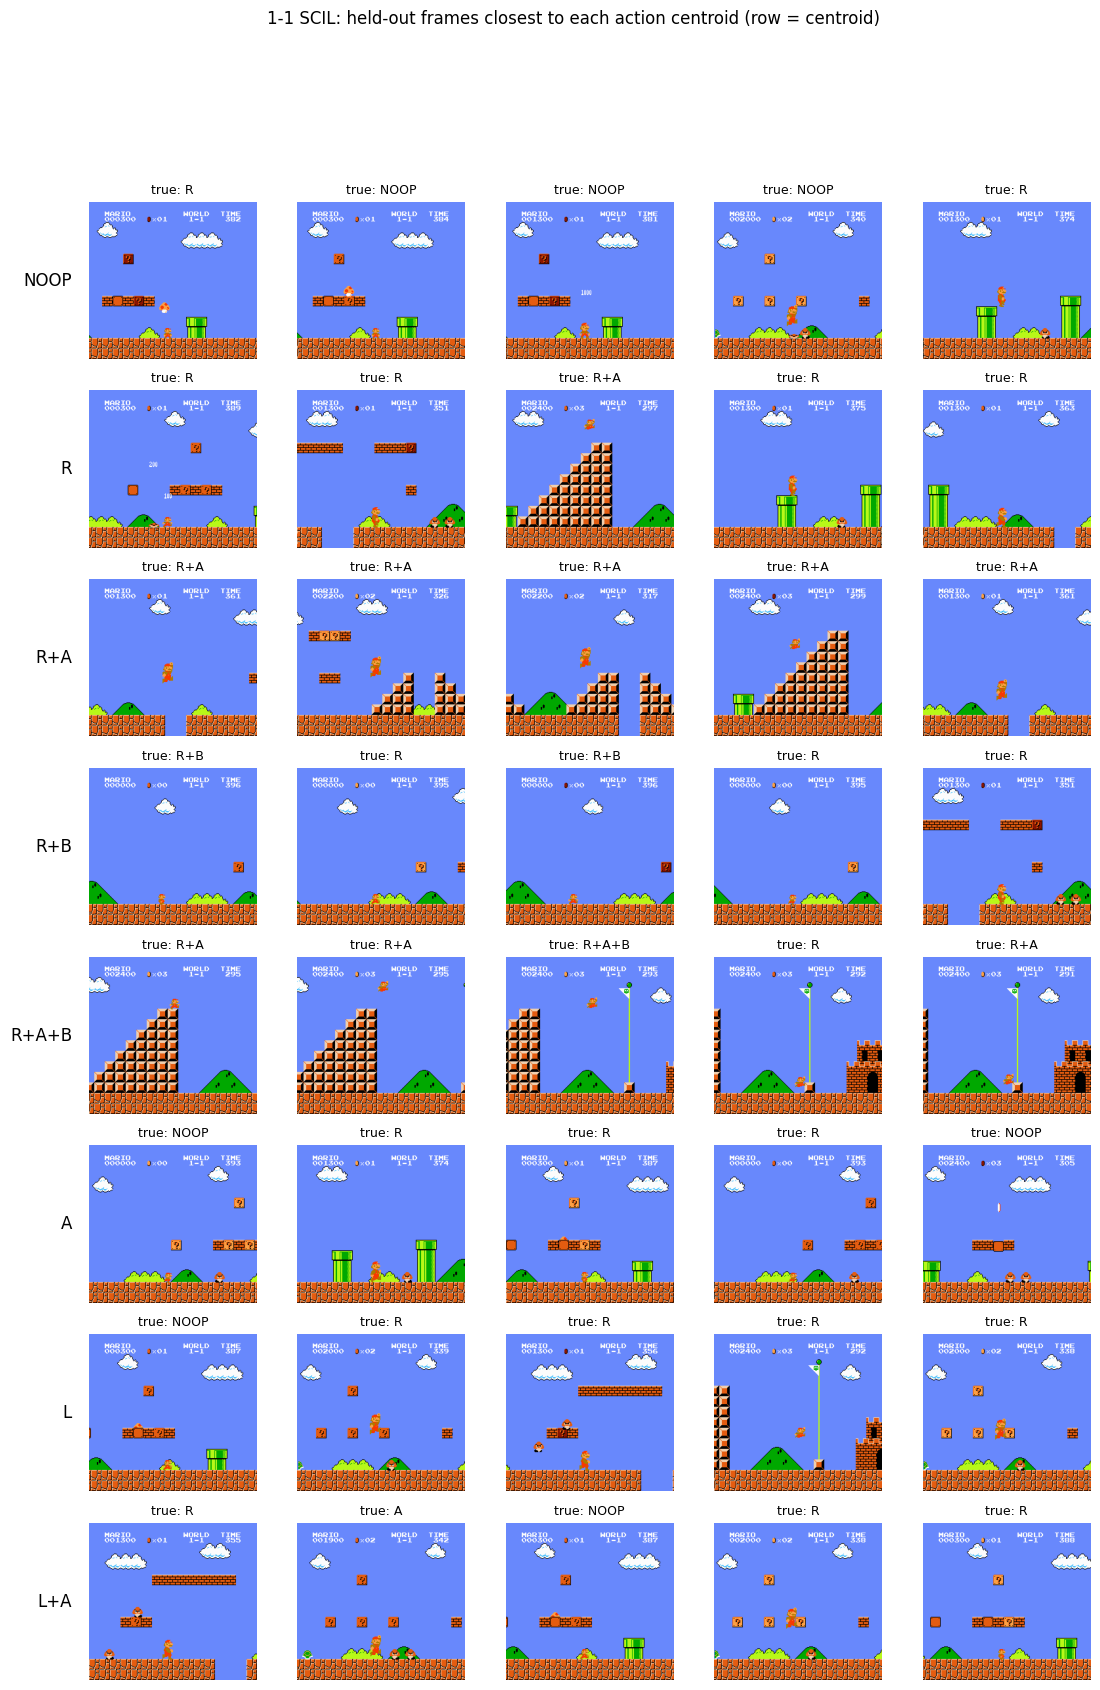

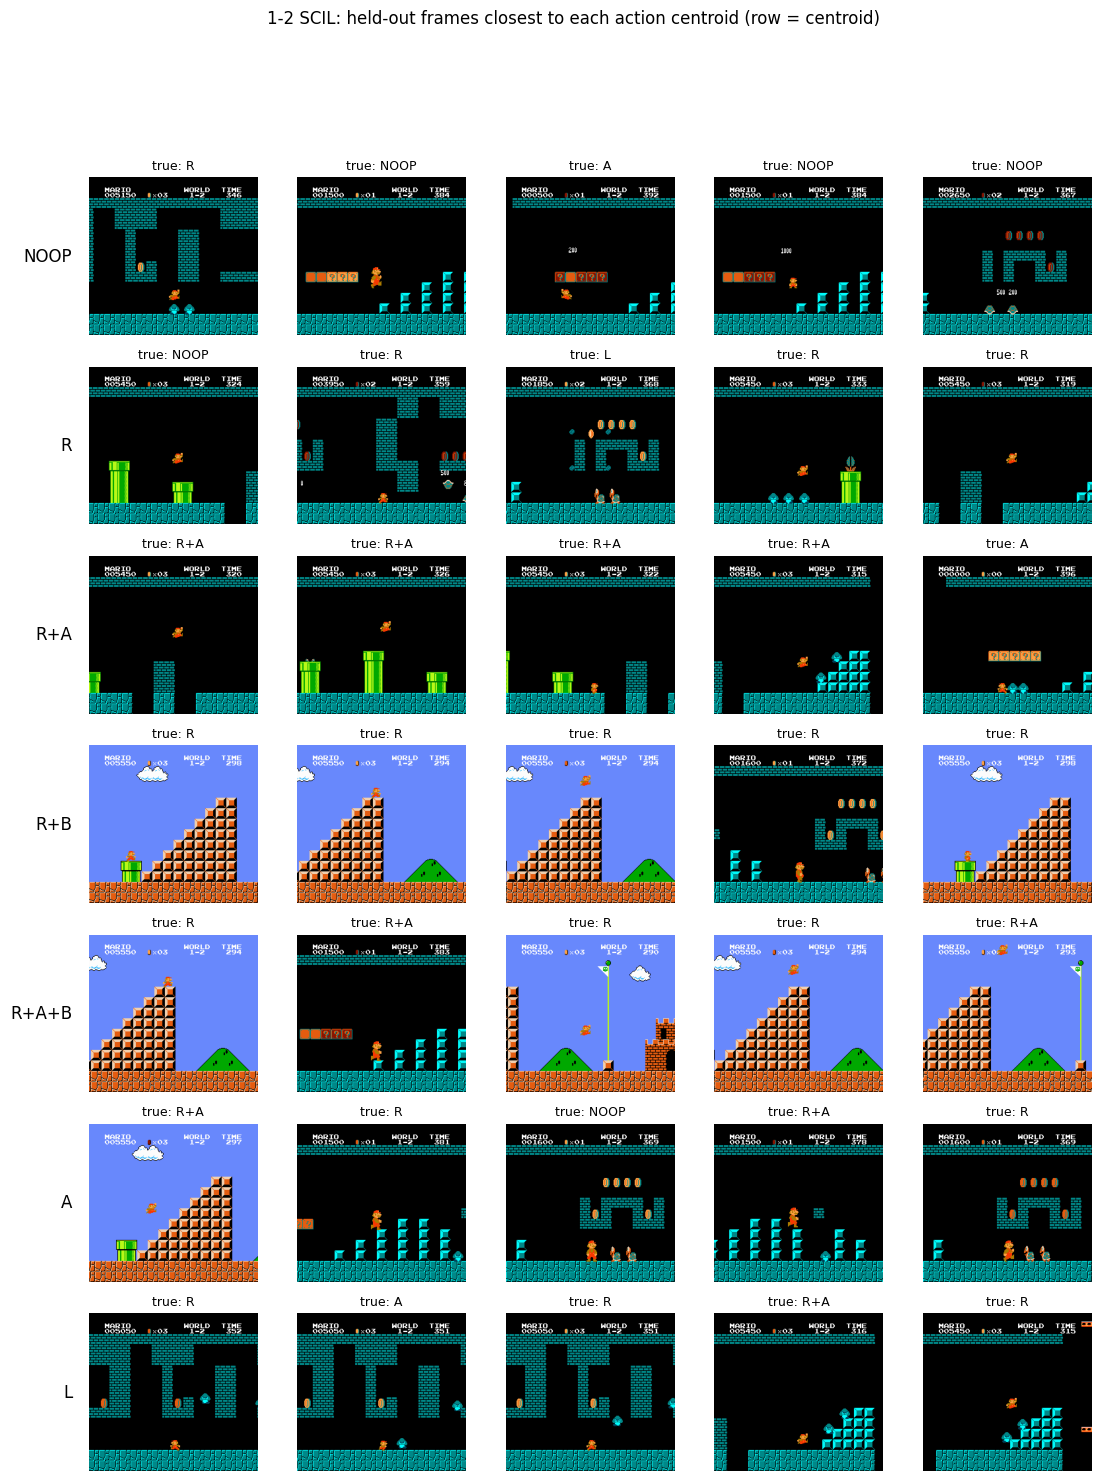

In [5]:
cluster_gallery("1-1")
cluster_gallery("1-2")

## 1. No alignment (BC): the two latent spaces are unrelated

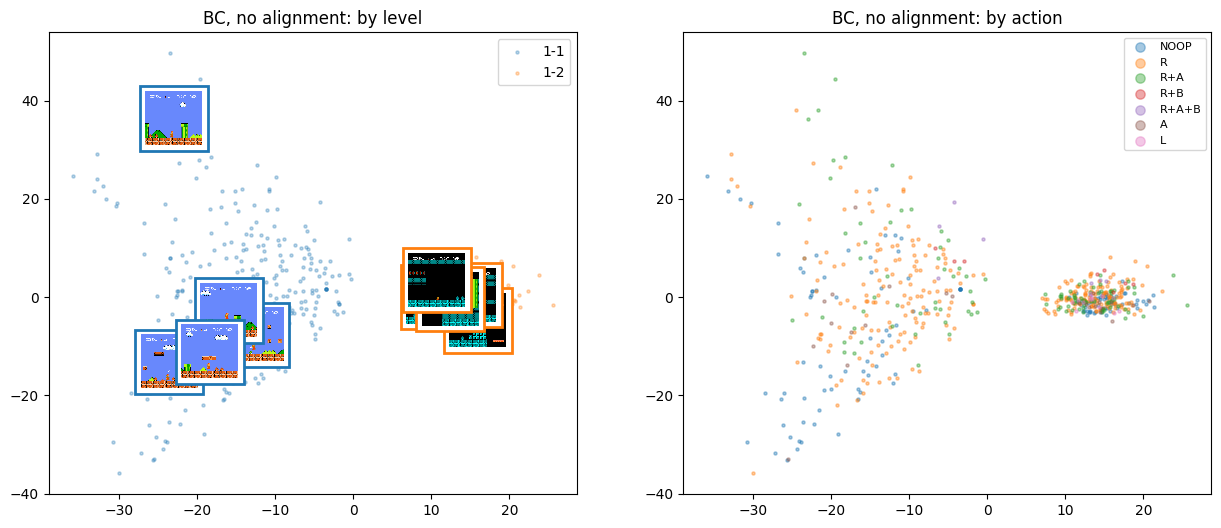

In [6]:
Z = {L: latents("bc", L, [VAL_EP[L]]) for L in SEED}
plot_spaces("BC, no alignment", *Z["1-1"], *Z["1-2"])

## 2. BC + SAPS, anchors = random frames with the same action

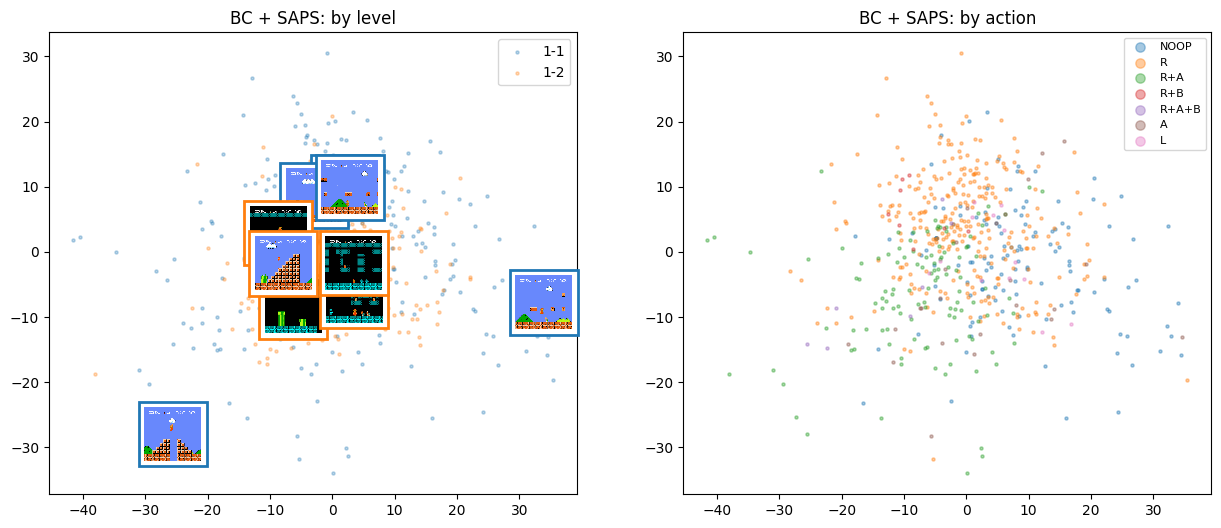

In [7]:
R, b = same_action_map("bc", "1-1", "1-2")
Z11_bc = Z["1-1"][0] @ R.T + b
plot_spaces("BC + SAPS", Z11_bc, Z["1-1"][1], *Z["1-2"])

## 3. SCIL + SAPS, anchors = random frames with the same action

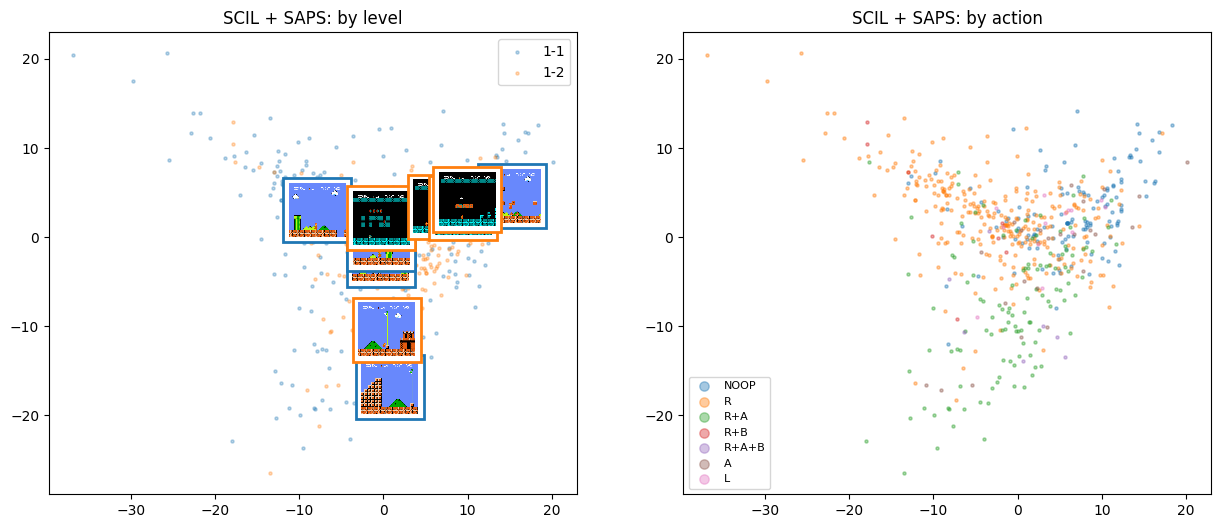

In [8]:
S = {L: latents("scil", L, [VAL_EP[L]]) for L in SEED}
R, b = same_action_map("scil", "1-1", "1-2")
S11_map = S["1-1"][0] @ R.T + b
plot_spaces("SCIL + SAPS", S11_map, S["1-1"][1], *S["1-2"])

## 4. Neighbours across levels (same 1-1 frames for both)

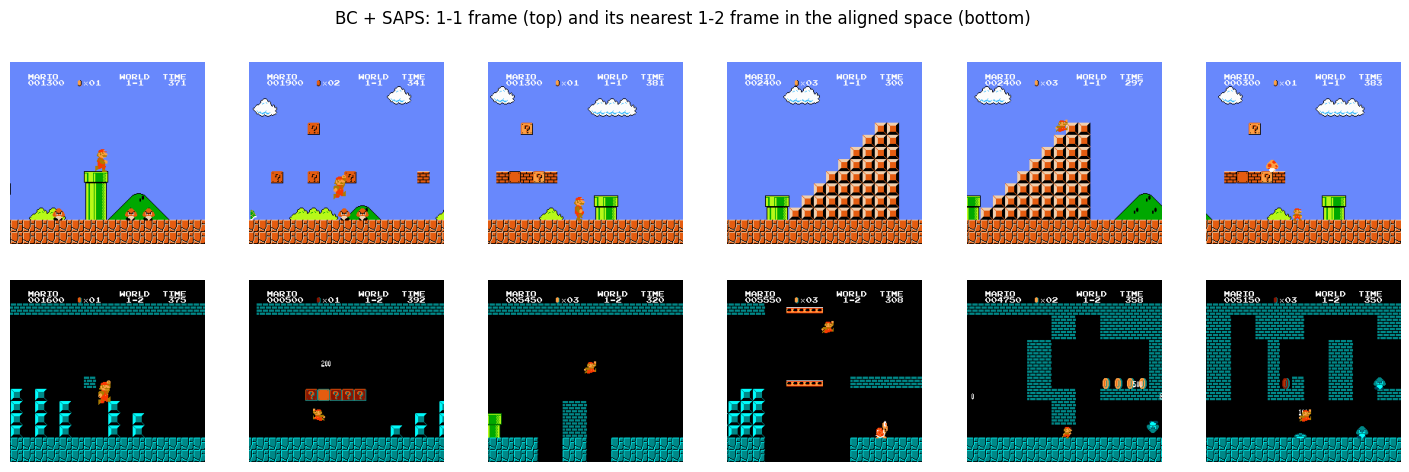

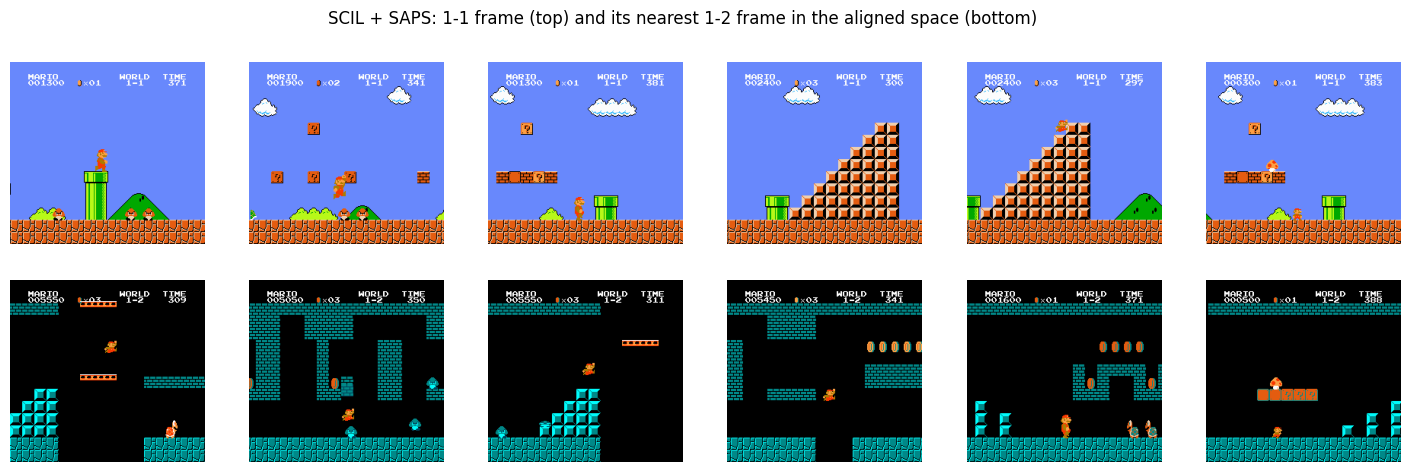

In [9]:
idx = rng.choice(len(F["1-1"]), 6, replace=False)
show_neighbours("BC + SAPS", Z11_bc, Z["1-2"][0], idx)
show_neighbours("SCIL + SAPS", S11_map, S["1-2"][0], idx)

## 5. Does the other level's controller act correctly through the map?
Held-out frames of the played level. *Agreement* = how often the stitched agent (own encoder + map + other level's
controller) picks the same action as the native agent of that level. Without a map, the other controller is at chance.
In-game results for the same stitches: `results/20260929_stitch_levels_*`.

In [10]:
for method in ["bc", "scil"]:
    for play, other in [("1-1", "1-2"), ("1-2", "1-1")]:
        agree, agree_nomap, _, _ = stitch_check(method, play, other)
        print(f"{method.upper():4s} play {play} with {other}'s controller: agreement {agree:.2f} (no map: {agree_nomap:.2f})")

BC   play 1-1 with 1-2's controller: agreement 0.62 (no map: 0.37)


BC   play 1-2 with 1-1's controller: agreement 0.72 (no map: 0.44)


SCIL play 1-1 with 1-2's controller: agreement 0.88 (no map: 0.19)


SCIL play 1-2 with 1-1's controller: agreement 0.87 (no map: 0.48)


SCIL, playing 1-1 with the 1-2 controller: native action vs stitched action on held-out 1-1 frames.

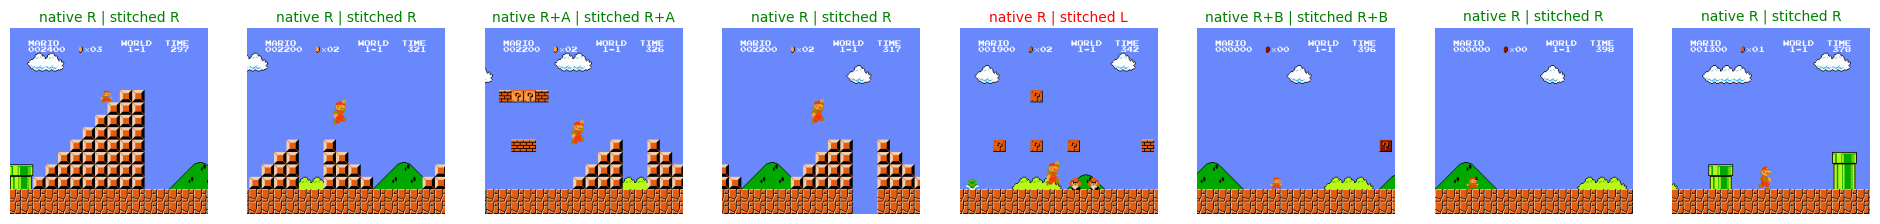

In [11]:
_, _, native, stitched = stitch_check("scil", "1-1", "1-2")
idx = rng.choice(len(F["1-1"]), 8, replace=False)
fig, axes = plt.subplots(1, 8, figsize=(24, 3.4))
for ax, i in zip(axes, idx):
    ax.imshow(F["1-1"][i])
    ax.set_title(f"native {CLASS_NAMES[native[i]]} | stitched {CLASS_NAMES[stitched[i]]}",
                 color="green" if native[i] == stitched[i] else "red", fontsize=10)
    ax.axis("off")
plt.show()

## 6. What the SAPS map does, step by step (SCIL, training frames)
1. The two SCIL spaces, each seen on its own: 1-1 as circles, 1-2 as squares, colour = action, big markers = action centroids.
2. The 1-1 latents mapped into the 1-2 space with SAPS (same-action anchors), overlaid on 1-2.
3. The map applied gradually: a fraction t of the rotation and of the shift, t = 0 → 1 (points follow the rotation, not a straight line).

All three use 2-D PCA; plots 2 and 3 use the PCA of the 1-2 space, so the 1-2 squares stay fixed.

In [12]:
# SECTION6 helpers
from matplotlib import animation
from IPython.display import HTML
from scipy.linalg import expm, logm

STEP = 24  # training frames: keep one out of STEP
COLORS = {c: f"C{c}" for c in range(len(CLASS_NAMES))}
MARK = {"1-1": "o", "1-2": "s"}


def scil_space(level):
    # SCIL latents of the level's own encoder on its training frames, and their actions
    enc, _ = load_model(ARCH, "scil", SEED[level], level, 0)
    X, y, _ = inputs(ARCH, level, 0, EPISODES[level][0])
    return embed(ARCH, enc, X[::STEP]), y.numpy()[::STEP]


def proper_same_action_map(src, tgt):
    # Same anchors as the method (align.action_pairs, full training sets, <=100 per action), but Procrustes
    # constrained to a proper rotation (det = +1, as in the old repo) so it can be interpolated.
    # Returns Q, b with z_mapped = z @ Q + b.
    Za, ya = latents("scil", src, EPISODES[src][0], every=1)
    Zb, yb = latents("scil", tgt, EPISODES[tgt][0], every=1)
    ia, ib = action_pairs(ya, yb, rng)
    As, Bs = Za[ia], Zb[ib]
    mu_a, mu_b = As.mean(0), Bs.mean(0)
    U, _, Vt = np.linalg.svd((As - mu_a).T @ (Bs - mu_b))
    if np.linalg.det(U @ Vt) < 0:
        U[:, -1] *= -1
    Q = U @ Vt
    return Q, mu_b - mu_a @ Q


def pca_basis(Z):
    mu = Z.mean(0)
    _, _, Vt = np.linalg.svd(Z - mu, full_matrices=False)
    return lambda W: (W - mu) @ Vt[:2].T


def draw(ax, P, y, level, alpha=0.35):
    # points + one big marker per action centroid
    for c in np.unique(y):
        ax.scatter(*P[y == c].T, s=12, marker=MARK[level], c=COLORS[c], alpha=alpha, edgecolors="none")
        ax.scatter(*P[y == c].mean(0), s=260, marker=MARK[level], c=COLORS[c], edgecolors="k", linewidths=1.5)


def legend(ax):
    hs = [plt.Line2D([], [], ls="", marker="o", color=COLORS[c], label=CLASS_NAMES[c]) for c in range(len(CLASS_NAMES))]
    hs += [plt.Line2D([], [], ls="", marker=MARK[L], mfc="w", mec="k", label=f"level {L}") for L in MARK]
    ax.legend(handles=hs, fontsize=8, loc="best")


A, ya = scil_space("1-1")
B, yb = scil_space("1-2")
Q, b = proper_same_action_map("1-1", "1-2")
to2d = pca_basis(B)  # the 1-2 view, used for plots 2 and 3

### 6.1 The two SCIL spaces, each on its own

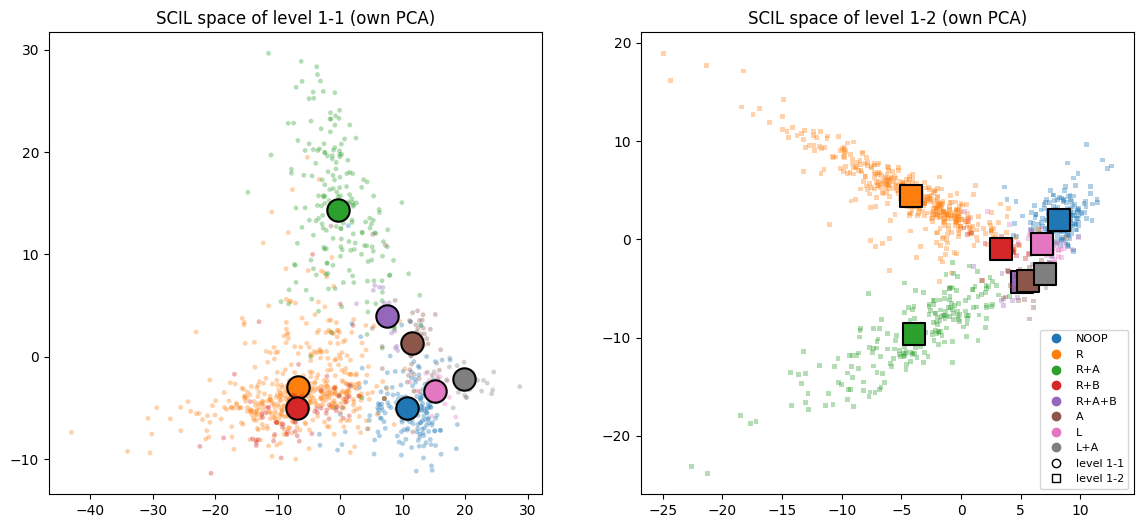

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, Z, y, L in [(axes[0], A, ya, "1-1"), (axes[1], B, yb, "1-2")]:
    draw(ax, pca_basis(Z)(Z), y, L)
    ax.set_title(f"SCIL space of level {L} (own PCA)")
legend(axes[1])
plt.show()

### 6.2 After SAPS: 1-1 mapped into the 1-2 space

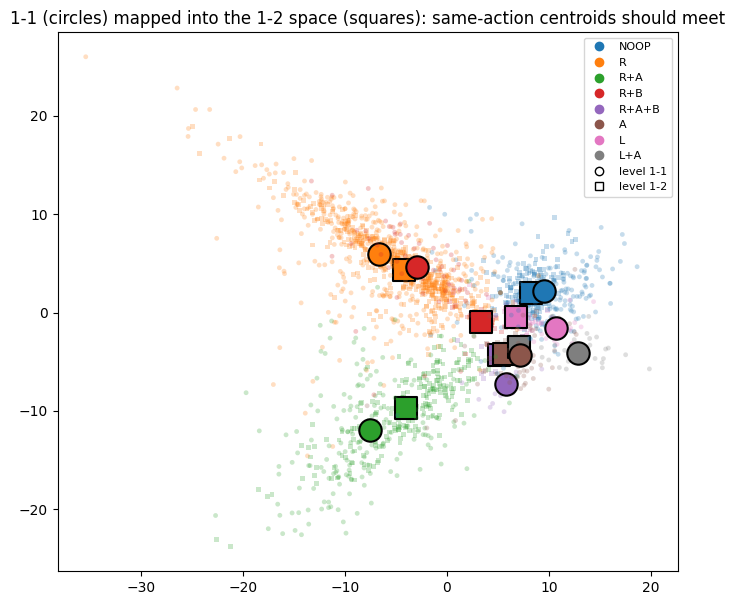

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
draw(ax, to2d(B), yb, "1-2", alpha=0.25)
draw(ax, to2d(A @ Q + b), ya, "1-1", alpha=0.25)
ax.set_title("1-1 (circles) mapped into the 1-2 space (squares): same-action centroids should meet")
legend(ax)
plt.show()

### 6.3 The map applied gradually: z(t) = z Q^t + t b, t = 0 → 1

In [15]:
L = np.real(logm(Q))  # generator of the rotation: Q^t = expm(t L)
ts = np.linspace(0, 1, 31)
paths = [to2d(A @ np.real(expm(t * L)) + t * b) for t in ts]  # (T, N, 2) projected 1-1 positions
PB = to2d(B)
lim = np.concatenate(paths + [PB])
pad = 0.05 * (lim.max(0) - lim.min(0))

fig, ax = plt.subplots(figsize=(8, 7))
draw(ax, PB, yb, "1-2", alpha=0.2)
pts = {c: ax.scatter([], [], s=12, marker="o", c=COLORS[c], alpha=0.5, edgecolors="none") for c in np.unique(ya)}
cen = {c: ax.scatter([], [], s=260, marker="o", c=COLORS[c], edgecolors="k", linewidths=1.5) for c in np.unique(ya)}
ax.set_xlim(lim[:, 0].min() - pad[0], lim[:, 0].max() + pad[0])
ax.set_ylim(lim[:, 1].min() - pad[1], lim[:, 1].max() + pad[1])
legend(ax)


def update(k):
    for c in pts:
        pts[c].set_offsets(paths[k][ya == c])
        cen[c].set_offsets(paths[k][ya == c].mean(0, keepdims=True))
    ax.set_title(f"1-1 latents moving into the 1-2 space, t = {ts[k]:.2f}")


anim = animation.FuncAnimation(fig, update, frames=len(ts), interval=120)
plt.close(fig)
HTML(anim.to_jshtml())